In [2]:
# # Two-Stage Neural Network for Dynamic Adaptive Compression

# **Problem:** At each TTI, choose the optimal compression level (components ∈ {25, 50, …, 400}) for each user to minimize effective error (QoE).

# **Two-Stage Approach:**

# | | Stage 1: Error Predictor | Stage 2: Direct Selector |
# |---|---|---|
# | **Task** | Regression: predict effective error | Classification: output optimal compression level |
# | **Input** | All users' features **including** components | All users' features **excluding** components |
# | **Output** | Predicted error per user (continuous) | Optimal compression class per user (16 classes) |
# | **Training data** | Real dataset | Synthetic labels from Stage 1 sweeps |
# | **Inference** | Only used offline for label generation | **Single forward pass** at runtime |

# **Result:** ~500× faster inference — one forward pass instead of coordinate descent with hundreds of passes.

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, top_k_accuracy_score
import matplotlib.pyplot as plt
import os, json, copy, pickle, time

# ── Configuration ──────────────────────────────────────────────
DATASET_PATH    = "datasets/random_cl_dataset_clean.csv"
STAGE1_DIR      = "models"             # Stage 1 models (from model.ipynb)
STAGE2_DIR      = "models_stage2"
os.makedirs(STAGE2_DIR, exist_ok=True)

COMP_LEVELS     = list(range(25, 401, 25))   # 16 levels
COMP_TO_IDX     = {c: i for i, c in enumerate(COMP_LEVELS)}
NUM_COMP_LEVELS = len(COMP_LEVELS)
CQI_MIN, CQI_MAX = 6, 15
CQI_VOCAB_SIZE  = CQI_MAX - CQI_MIN + 1     # 10
CQI_EMBED_DIM   = 4

# Stage 1 config (must match model.ipynb)
S1_HIDDEN       = [256, 128, 64]
S1_CONT_FEATS   = ['meantrafficsize', 'stdtrafficsize', 'frameComplexity', 'components']
NUM_S1_CONT     = len(S1_CONT_FEATS)

# Stage 2 config
S2_HIDDEN       = [256, 128]
S2_BATCH        = 256
S2_LR           = 1e-3
S2_EPOCHS       = 200
S2_PATIENCE     = 20

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Stage 1 models: {STAGE1_DIR}/")
print(f"Stage 2 output: {STAGE2_DIR}/")

Device: cuda
Stage 1 models: models/
Stage 2 output: models_stage2/


## 1. Load Data & Stage 1 Models

Load the dataset and the pre-trained Stage 1 error predictor models from `model.ipynb`.

In [4]:
# ── Stage 1 model definition (must match model.ipynb) ─────────
class CompressionPredictor(nn.Module):
    """Stage 1: predicts log(1+effectiveError) for each user."""
    def __init__(self, num_users, cqi_vocab=CQI_VOCAB_SIZE,
                 cqi_dim=CQI_EMBED_DIM, hidden=None):
        super().__init__()
        if hidden is None:
            hidden = S1_HIDDEN
        self.num_users = num_users
        self.cqi_embed = nn.Embedding(cqi_vocab, cqi_dim)
        per_user = NUM_S1_CONT + cqi_dim   # 4 + 4 = 8
        in_dim   = num_users * per_user
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers.append(nn.Linear(prev, num_users))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_cqi):
        cqi_emb = self.cqi_embed(x_cqi)
        x = torch.cat([x_cont, cqi_emb], dim=-1)
        x = x.view(x.size(0), -1)
        return self.net(x)


# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv(DATASET_PATH)
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"User configs: {sorted(df['num_users'].unique())}")

# ── Load global scaler ────────────────────────────────────────
with open(os.path.join(STAGE1_DIR, 'global_scaler.pkl'), 'rb') as f:
    global_scaler = pickle.load(f)
print(f"Scaler loaded — means: {global_scaler.mean_}")

# ── Load all 9 Stage 1 models ────────────────────────────────
s1_models = {}
for n_u in range(2, 11):
    model = CompressionPredictor(n_u).to(DEVICE)
    path = os.path.join(STAGE1_DIR, f'model_{n_u}users.pt')
    model.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    model.eval()
    s1_models[n_u] = model
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Loaded {n_u}-user model ({n_params:,} params)")

print(f"\n✓ All 9 Stage 1 models loaded.")

Dataset: 33504 rows, 72 columns
User configs: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Scaler loaded — means: [19339.89776903 54767.85275807 19055.05652805   212.01753576]
  Loaded 2-user model (46,570 params)
  Loaded 3-user model (48,683 params)
  Loaded 4-user model (50,796 params)
  Loaded 5-user model (52,909 params)
  Loaded 6-user model (55,022 params)
  Loaded 7-user model (57,135 params)
  Loaded 8-user model (59,248 params)
  Loaded 9-user model (61,361 params)
  Loaded 10-user model (63,474 params)

✓ All 9 Stage 1 models loaded.


## 2. Generate Labels via Stage 1 Sweep

For each row in the dataset, we:
1. Take each user's **static features** (meantrafficsize, stdtrafficsize, frameComplexity, CQI) — everything *except* compression level.
2. Sweep all 16 compression levels through the Stage 1 model.
3. For each user, the **optimal compression label** = argmin of predicted effective error across 16 levels.

This produces a fully-labeled classification dataset where the Stage 1 model acts as the oracle.

In [5]:
def extract_static_features(df, num_users):
    """Extract per-user features WITHOUT compression level.
    Returns: static_cont (n, N, 3), cqi_idx (n, N), original_comp (n, N)
    """
    subset = df[df['num_users'] == num_users].reset_index(drop=True)
    n = len(subset)
    STATIC_NAMES = ['meantrafficsize', 'stdtrafficsize', 'frameComplexity']

    static_cont  = np.zeros((n, num_users, 3), dtype=np.float32)
    cqi_idx      = np.zeros((n, num_users), dtype=np.int64)
    original_comp= np.zeros((n, num_users), dtype=np.int64)
    actual_error = np.zeros((n, num_users), dtype=np.float32)

    for u in range(num_users):
        for j, feat in enumerate(STATIC_NAMES):
            static_cont[:, u, j] = subset[f'user{u}_{feat}'].values
        cqi_idx[:, u]       = subset[f'user{u}_cqi'].values.astype(int) - CQI_MIN
        original_comp[:, u] = subset[f'user{u}_components'].values.astype(int)
        actual_error[:, u]  = subset[f'user{u}_effectiveError'].values

    return static_cont, cqi_idx, original_comp, actual_error


@torch.no_grad()
def generate_labels(s1_model, static_cont, cqi_idx, scaler, batch_size=512):
    """
    Sweep all 16 compression levels through Stage 1 to find per-user optima.

    Returns:
        opt_labels : (n, N) int  — index of optimal compression per user (0-15)
        all_errors : (n, N, 16) float — predicted errors at all 16 levels
    """
    s1_model.eval()
    n, N, _ = static_cont.shape
    all_errors = np.zeros((n, N, NUM_COMP_LEVELS), dtype=np.float32)

    for ci, comp_val in enumerate(COMP_LEVELS):
        # Build full 4-feature input: [static_feats..., comp_val]
        comp_col = np.full((n, N, 1), comp_val, dtype=np.float32)
        x_full   = np.concatenate([static_cont, comp_col], axis=-1)  # (n, N, 4)

        # Normalise with global scaler
        shape = x_full.shape
        x_scaled = scaler.transform(x_full.reshape(-1, NUM_S1_CONT)).reshape(shape)

        # Predict in batches
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            xc  = torch.tensor(x_scaled[start:end], dtype=torch.float32).to(DEVICE)
            xcq = torch.tensor(cqi_idx[start:end],  dtype=torch.long).to(DEVICE)
            pred_log = s1_model(xc, xcq)                     # (B, N)
            all_errors[start:end, :, ci] = torch.expm1(pred_log).cpu().numpy()

    # Optimal = argmin across compression levels, per user
    opt_labels = np.argmin(all_errors, axis=2)  # (n, N)
    return opt_labels, all_errors


# ── Generate labels for all 9 configurations ─────────────────
label_data = {}  # n_u -> (static_cont, cqi_idx, opt_labels, all_errors, orig_comp, actual_err)

for n_u in range(2, 11):
    sc, cq, oc, ae = extract_static_features(df, n_u)
    opt_labels, all_errors = generate_labels(s1_models[n_u], sc, cq, global_scaler)
    label_data[n_u] = (sc, cq, opt_labels, all_errors, oc, ae)

    opt_comp_vals = np.array(COMP_LEVELS)[opt_labels]
    print(f"num_users={n_u:>2d}  samples={len(sc):>5d}  "
          f"label distribution: {dict(zip(*np.unique(opt_labels, return_counts=True)))}")

print("\n✓ Labels generated for all configurations.")

num_users= 2  samples= 4530  label distribution: {np.int64(0): np.int64(21), np.int64(1): np.int64(17), np.int64(2): np.int64(46), np.int64(3): np.int64(34), np.int64(4): np.int64(80), np.int64(5): np.int64(182), np.int64(6): np.int64(282), np.int64(7): np.int64(525), np.int64(8): np.int64(1249), np.int64(9): np.int64(66), np.int64(10): np.int64(74), np.int64(11): np.int64(714), np.int64(12): np.int64(363), np.int64(13): np.int64(95), np.int64(14): np.int64(228), np.int64(15): np.int64(5084)}
num_users= 3  samples= 4204  label distribution: {np.int64(0): np.int64(474), np.int64(1): np.int64(58), np.int64(2): np.int64(73), np.int64(3): np.int64(87), np.int64(4): np.int64(169), np.int64(5): np.int64(277), np.int64(6): np.int64(219), np.int64(7): np.int64(351), np.int64(8): np.int64(1774), np.int64(9): np.int64(597), np.int64(10): np.int64(322), np.int64(11): np.int64(256), np.int64(12): np.int64(500), np.int64(13): np.int64(445), np.int64(14): np.int64(174), np.int64(15): np.int64(6836)}

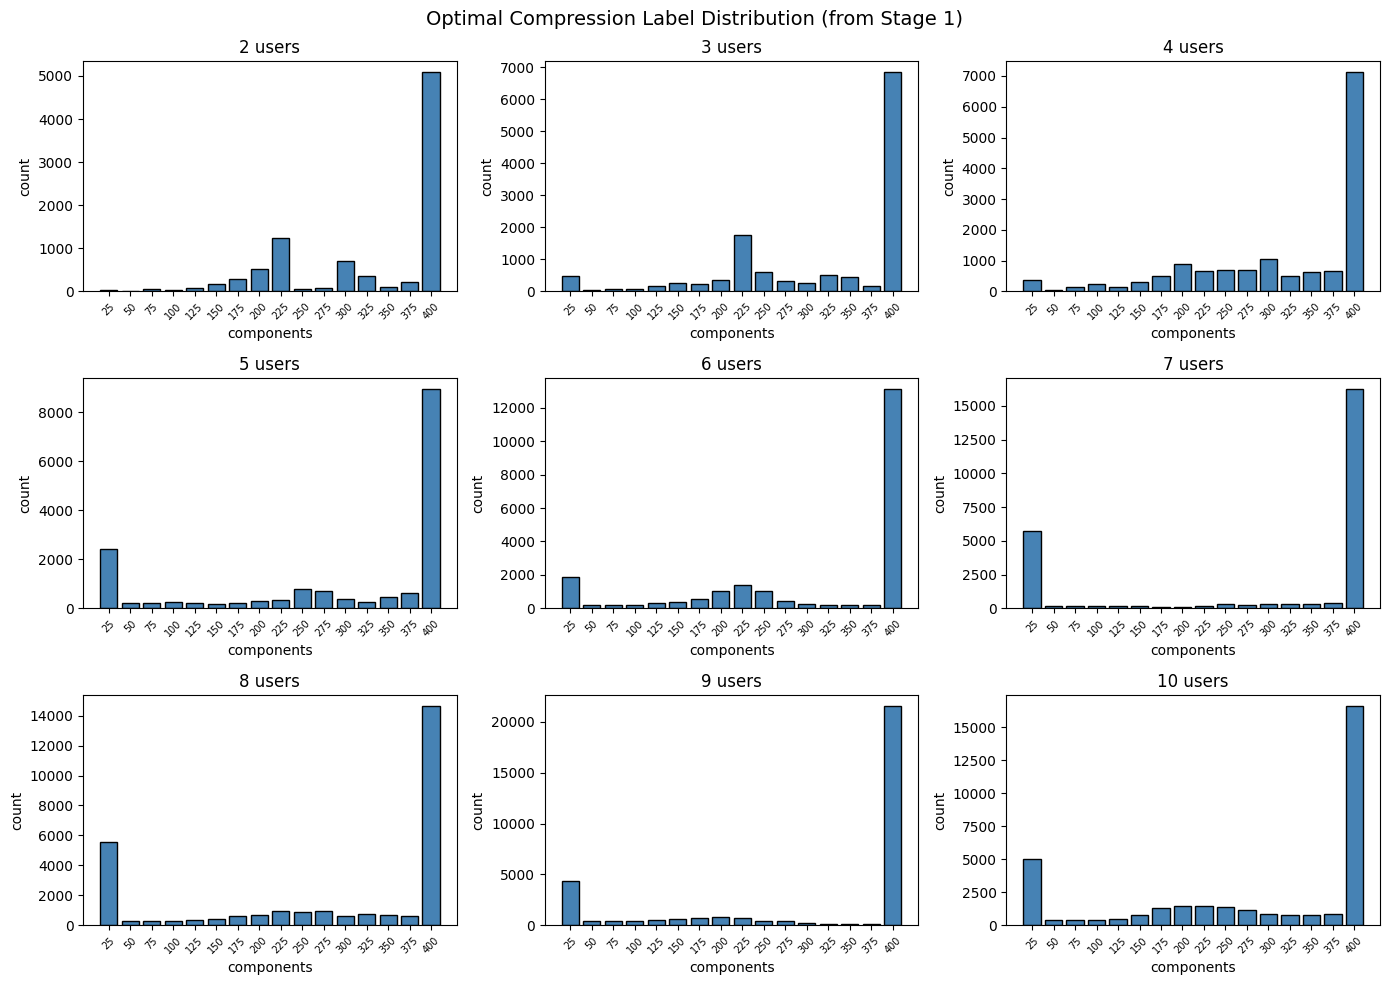

In [6]:
# ── Visualise label distribution ───────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for idx, n_u in enumerate(range(2, 11)):
    ax = axes[idx // 3][idx % 3]
    _, _, opt_labels, _, _, _ = label_data[n_u]
    all_labels = opt_labels.flatten()
    ax.bar(range(NUM_COMP_LEVELS),
           [np.sum(all_labels == i) for i in range(NUM_COMP_LEVELS)],
           tick_label=[str(c) for c in COMP_LEVELS], color='steelblue', edgecolor='k')
    ax.set_title(f'{n_u} users')
    ax.set_xlabel('components')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle('Optimal Compression Label Distribution (from Stage 1)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Stage 2: Direct Selector (Classifier)

Architecture:
- **Input per user (3 continuous):** `meantrafficsize`, `stdtrafficsize`, `frameComplexity` — NO compression level
- **CQI Embedding:** same 10-bin → 4-dim as Stage 1
- All users concatenated → captures cross-user dependencies
- **Hidden:** `[256 → 128]` with BatchNorm, ReLU, Dropout
- **Output:** `N × 16` logits — one 16-class classification head per user

Loss: Cross-entropy (with optional label smoothing to handle slight Stage 1 uncertainty)

In [7]:
class CompressionSelector(nn.Module):
    """
    Stage 2: directly outputs optimal compression class per user.

    Inputs
    ------
    x_cont : (B, N, 3)  – normalised [meantrafficsize, stdtrafficsize, frameComplexity]
    x_cqi  : (B, N)     – CQI index (0-9)

    Output
    ------
    (B, N, 16) – logits over 16 compression classes per user
    """

    def __init__(self, num_users, cqi_vocab=CQI_VOCAB_SIZE,
                 cqi_dim=CQI_EMBED_DIM, hidden=None):
        super().__init__()
        if hidden is None:
            hidden = S2_HIDDEN
        self.num_users = num_users
        self.cqi_embed = nn.Embedding(cqi_vocab, cqi_dim)

        per_user = 3 + cqi_dim                # 3 + 4 = 7  (no components!)
        in_dim   = num_users * per_user

        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(0.15)]
            prev = h
        # Output: N * 16 logits → reshape to (B, N, 16)
        layers.append(nn.Linear(prev, num_users * NUM_COMP_LEVELS))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_cqi):
        cqi_emb = self.cqi_embed(x_cqi)                         # (B, N, 4)
        x = torch.cat([x_cont, cqi_emb], dim=-1)                # (B, N, 7)
        x = x.view(x.size(0), -1)                               # (B, N*7)
        logits = self.net(x)                                     # (B, N*16)
        return logits.view(-1, self.num_users, NUM_COMP_LEVELS)  # (B, N, 16)


# Quick shape check
_m2 = CompressionSelector(num_users=5).to(DEVICE)
_x2 = torch.randn(2, 5, 3).to(DEVICE)
_c2 = torch.randint(0, CQI_VOCAB_SIZE, (2, 5)).to(DEVICE)
print(f"Stage 2 output shape: {_m2(_x2, _c2).shape}")  # (2, 5, 16)
print(f"Parameters (5-user selector): {sum(p.numel() for p in _m2.parameters()):,}")

Stage 2 output shape: torch.Size([2, 5, 16])
Parameters (5-user selector): 53,240


## 4. Prepare Stage 2 Datasets & Training

In [8]:
# ── Build a scaler for the 3 static features (no components) ──
STATIC_FEATS = ['meantrafficsize', 'stdtrafficsize', 'frameComplexity']

all_static = []
for n_u in range(2, 11):
    sc, _, _, _, _, _ = label_data[n_u]
    all_static.append(sc.reshape(-1, 3))

static_scaler = StandardScaler().fit(np.concatenate(all_static, axis=0))
print(f"Static scaler fitted — means: {static_scaler.mean_}, stds: {static_scaler.scale_}")


# ── Build per-config datasets ─────────────────────────────────
class SelectorDataset(Dataset):
    """Dataset for Stage 2 classifier."""
    def __init__(self, static_cont, cqi_idx, opt_labels, scaler):
        shape = static_cont.shape
        scaled = scaler.transform(static_cont.reshape(-1, 3)).reshape(shape)
        self.X_cont = torch.tensor(scaled, dtype=torch.float32)
        self.X_cqi  = torch.tensor(cqi_idx, dtype=torch.long)
        self.y      = torch.tensor(opt_labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cont[idx], self.X_cqi[idx], self.y[idx]


s2_datasets = {}  # n_u -> (train, val, test)
for n_u in range(2, 11):
    sc, cq, ol, _, _, _ = label_data[n_u]
    ds = SelectorDataset(sc, cq, ol, static_scaler)

    n_total = len(ds)
    n_test  = int(0.10 * n_total)
    n_val   = int(0.10 * n_total)
    n_train = n_total - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )
    s2_datasets[n_u] = (train_ds, val_ds, test_ds)
    print(f"num_users={n_u:>2d}  train={n_train}, val={n_val}, test={n_test}")

Static scaler fitted — means: [19339.89776903 54767.85275807 19055.05652805], stds: [17485.93573753 75414.32025216 93589.48973191]
num_users= 2  train=3624, val=453, test=453
num_users= 3  train=3364, val=420, test=420
num_users= 4  train=2934, val=366, test=366
num_users= 5  train=2651, val=331, test=331
num_users= 6  train=2888, val=361, test=361
num_users= 7  train=2873, val=358, test=358
num_users= 8  train=2874, val=359, test=359
num_users= 9  train=2849, val=356, test=356
num_users=10  train=2753, val=343, test=343


In [9]:
def train_selector(num_users, train_ds, val_ds,
                   epochs=S2_EPOCHS, patience=S2_PATIENCE):
    """Train a CompressionSelector for a given user count."""
    train_dl = DataLoader(train_ds, batch_size=S2_BATCH, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=S2_BATCH)

    model = CompressionSelector(num_users).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=S2_LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_val, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss = 0.0
        for xc, xcqi, yt in train_dl:
            xc, xcqi, yt = xc.to(DEVICE), xcqi.to(DEVICE), yt.to(DEVICE)
            logits = model(xc, xcqi)               # (B, N, 16)
            # Reshape for cross-entropy: (B*N, 16) vs (B*N,)
            loss = loss_fn(logits.reshape(-1, NUM_COMP_LEVELS), yt.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
            t_loss += loss.item() * xc.size(0)
        t_loss /= len(train_ds)

        # ── Validate ──
        model.eval()
        v_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xc, xcqi, yt in val_dl:
                xc, xcqi, yt = xc.to(DEVICE), xcqi.to(DEVICE), yt.to(DEVICE)
                logits = model(xc, xcqi)
                v_loss += loss_fn(logits.reshape(-1, NUM_COMP_LEVELS),
                                  yt.reshape(-1)).item() * xc.size(0)
                preds = logits.argmax(dim=-1)      # (B, N)
                correct += (preds == yt).sum().item()
                total   += yt.numel()
        v_loss /= len(val_ds)
        v_acc = correct / total
        sched.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_loss < best_val:
            best_val = v_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {ep}")
                break

        if ep % 25 == 0 or ep == 1:
            print(f"  Epoch {ep:>3d}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  "
                  f"val_acc={v_acc:.3f}  lr={opt.param_groups[0]['lr']:.1e}")

    model.load_state_dict(best_state)
    return model, history

In [10]:
# ── Train all 9 Stage 2 models ────────────────────────────────
s2_models    = {}
s2_histories = {}

for n_u in range(2, 11):
    print(f"\n{'='*55}")
    print(f"Training Stage 2 selector for num_users = {n_u}")
    print(f"{'='*55}")
    train_ds, val_ds, test_ds = s2_datasets[n_u]
    model, hist = train_selector(n_u, train_ds, val_ds)
    s2_models[n_u]    = model
    s2_histories[n_u] = hist
    print(f"  Best val loss: {min(hist['val_loss']):.4f}  "
          f"Best val acc: {max(hist['val_acc']):.3f}")

print("\n✓ All 9 Stage 2 models trained.")


Training Stage 2 selector for num_users = 2
  Epoch   1  train_loss=2.1800  val_loss=1.9442  val_acc=0.556  lr=1.0e-03
  Epoch  25  train_loss=0.5857  val_loss=0.5612  val_acc=0.909  lr=1.0e-03
  Epoch  50  train_loss=0.5183  val_loss=0.5076  val_acc=0.930  lr=5.0e-04
  Epoch  75  train_loss=0.4959  val_loss=0.4798  val_acc=0.938  lr=2.5e-04
  Epoch 100  train_loss=0.4875  val_loss=0.5019  val_acc=0.924  lr=1.3e-04
  Early stop at epoch 105
  Best val loss: 0.4713  Best val acc: 0.949

Training Stage 2 selector for num_users = 3
  Epoch   1  train_loss=2.2126  val_loss=2.1228  val_acc=0.506  lr=1.0e-03
  Epoch  25  train_loss=0.7232  val_loss=0.7176  val_acc=0.860  lr=1.0e-03
  Epoch  50  train_loss=0.6293  val_loss=0.6280  val_acc=0.893  lr=1.0e-03
  Epoch  75  train_loss=0.5890  val_loss=0.6007  val_acc=0.892  lr=1.0e-03
  Epoch 100  train_loss=0.5593  val_loss=0.5833  val_acc=0.906  lr=5.0e-04
  Epoch 125  train_loss=0.5516  val_loss=0.5767  val_acc=0.909  lr=2.5e-04
  Epoch 150  t

## 5. Evaluation

Metrics:
1. **Selection accuracy** — does Stage 2 pick the same compression as the Stage 1 oracle?
2. **Top-3 accuracy** — is the oracle's choice in Stage 2's top 3 predictions?
3. **QoE comparison** — compare predicted effective error of Stage 2's choice vs Stage 1 oracle vs random
4. **Inference speed** — Stage 2 single pass vs Stage 1 coordinate descent

In [11]:
@torch.no_grad()
def evaluate_selector(s2_model, s1_model, test_ds, static_cont_all, cqi_all,
                      all_errors_all, scaler_s1, scaler_s2):
    """
    Evaluate Stage 2 on test set. Returns dict of metrics.
    """
    s2_model.eval(); s1_model.eval()
    dl = DataLoader(test_ds, batch_size=512)
    all_preds, all_labels = [], []

    for xc, xcqi, yt in dl:
        xc, xcqi = xc.to(DEVICE), xcqi.to(DEVICE)
        logits = s2_model(xc, xcqi)         # (B, N, 16)
        all_preds.append(logits.cpu())
        all_labels.append(yt)

    all_preds  = torch.cat(all_preds)       # (T, N, 16)
    all_labels = torch.cat(all_labels)      # (T, N)
    pred_cls   = all_preds.argmax(dim=-1)   # (T, N)

    T, N = all_labels.shape

    # ── Accuracy metrics ──
    flat_preds  = pred_cls.numpy().flatten()
    flat_labels = all_labels.numpy().flatten()
    acc_top1 = accuracy_score(flat_labels, flat_preds)

    # Top-3 accuracy
    flat_probs = F.softmax(all_preds, dim=-1).numpy().reshape(-1, NUM_COMP_LEVELS)
    acc_top3 = top_k_accuracy_score(flat_labels, flat_probs, k=3,
                                     labels=list(range(NUM_COMP_LEVELS)))

    # ── QoE comparison using Stage 1 error surface ──
    # Get test set indices
    test_indices = test_ds.indices if hasattr(test_ds, 'indices') else list(range(len(test_ds)))

    # S1 oracle errors (at optimal compression)
    oracle_labels = all_labels.numpy()                             # (T, N)
    s2_labels     = pred_cls.numpy()                               # (T, N)

    oracle_errors = np.zeros((T, N))
    s2_errors     = np.zeros((T, N))
    random_errors = np.zeros((T, N))

    for i, tidx in enumerate(test_indices):
        for u in range(N):
            oracle_errors[i, u] = all_errors_all[tidx, u, oracle_labels[i, u]]
            s2_errors[i, u]     = all_errors_all[tidx, u, s2_labels[i, u]]
            random_errors[i, u] = all_errors_all[tidx, u, np.random.randint(NUM_COMP_LEVELS)]

    return {
        'top1_acc': acc_top1,
        'top3_acc': acc_top3,
        'oracle_err_mean': oracle_errors.mean(),
        's2_err_mean': s2_errors.mean(),
        'random_err_mean': random_errors.mean(),
        'oracle_err_per_sample': oracle_errors.sum(axis=1),  # sum across users
        's2_err_per_sample': s2_errors.sum(axis=1),
    }


# ── Evaluate all configs ──────────────────────────────────────
eval_results = {}
print(f"{'Config':>8s}  {'Top-1':>6s}  {'Top-3':>6s}  {'Oracle err':>10s}  "
      f"{'S2 err':>10s}  {'Random err':>10s}  {'S2/Oracle':>9s}")
print("-" * 75)

for n_u in range(2, 11):
    _, _, test_ds = s2_datasets[n_u]
    sc, cq, ol, ae, oc, actual = label_data[n_u]
    res = evaluate_selector(
        s2_models[n_u], s1_models[n_u], test_ds,
        sc, cq, ae, global_scaler, static_scaler
    )
    eval_results[n_u] = res
    ratio = res['s2_err_mean'] / res['oracle_err_mean']
    print(f"{n_u:>8d}  {res['top1_acc']:>6.1%}  {res['top3_acc']:>6.1%}  "
          f"{res['oracle_err_mean']:>10.2f}  {res['s2_err_mean']:>10.2f}  "
          f"{res['random_err_mean']:>10.2f}  {ratio:>9.2f}×")

  Config   Top-1   Top-3  Oracle err      S2 err  Random err  S2/Oracle
---------------------------------------------------------------------------
       2   94.8%  100.0%       44.78       44.99       66.30       1.00×
       3   91.8%   98.9%      125.95      126.37      182.98       1.00×
       4   88.5%   96.8%       73.60       74.12      125.24       1.01×
       5   90.0%   96.7%      112.84      115.12      177.89       1.02×
       6   87.9%   95.8%       84.72       86.57      150.95       1.02×
       7   92.1%   97.1%       80.80       81.54      140.32       1.01×
       8   85.7%   94.7%      125.25      126.13      184.31       1.01×
       9   87.0%   95.0%       94.11       95.67      153.48       1.02×
      10   78.2%   90.9%       98.89      101.64      177.51       1.03×


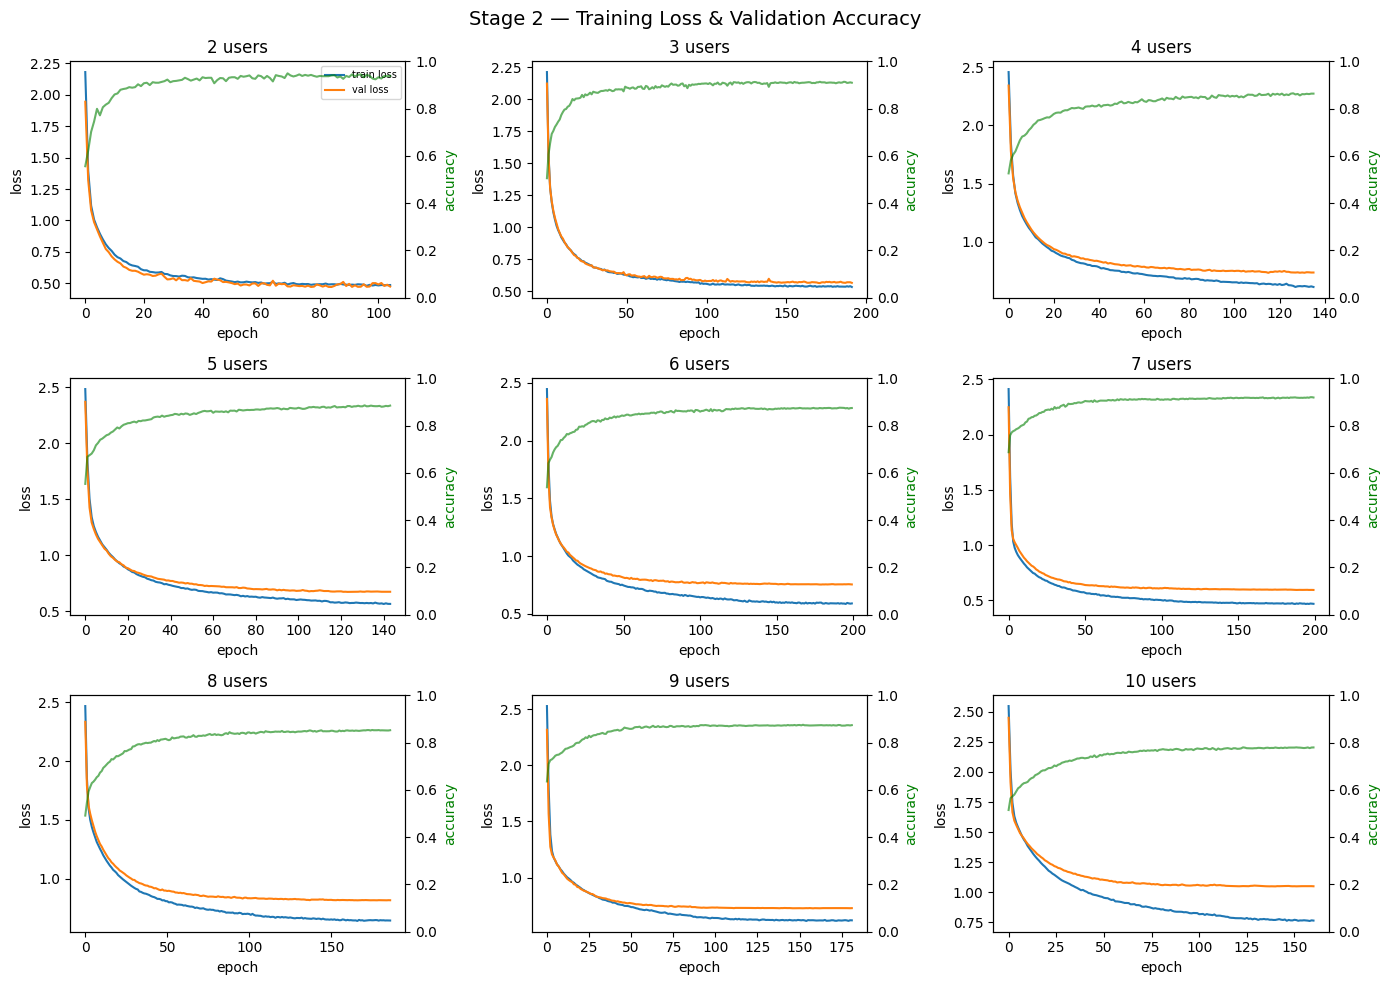

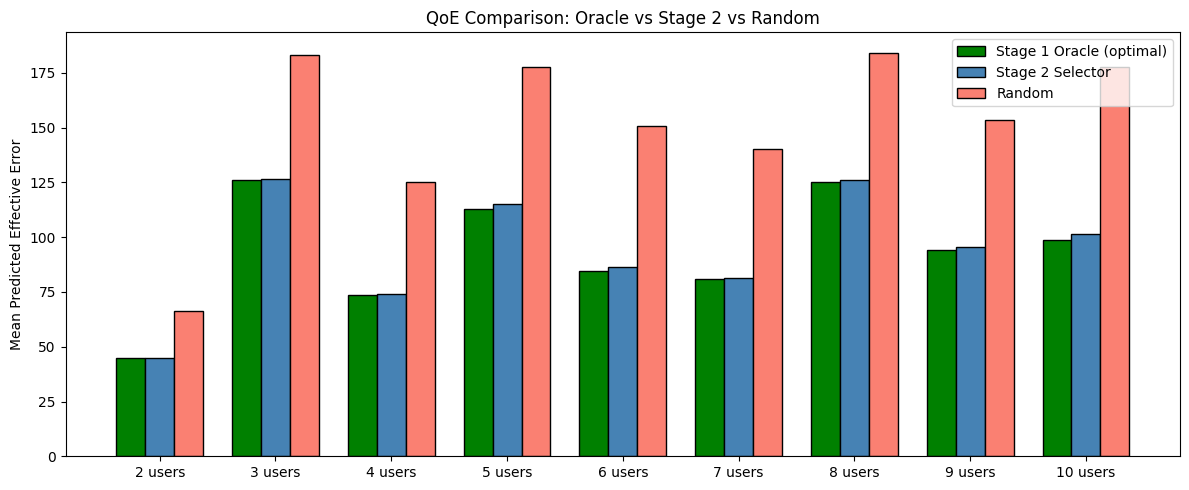

In [12]:
# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for idx, n_u in enumerate(range(2, 11)):
    ax = axes[idx // 3][idx % 3]
    h = s2_histories[n_u]
    ax.plot(h['train_loss'], label='train loss')
    ax.plot(h['val_loss'],   label='val loss')
    ax2 = ax.twinx()
    ax2.plot(h['val_acc'], color='green', alpha=0.6, label='val acc')
    ax2.set_ylim(0, 1)
    ax.set_title(f'{n_u} users')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax2.set_ylabel('accuracy', color='green')
    if idx == 0:
        ax.legend(loc='upper right', fontsize=7)
plt.suptitle('Stage 2 — Training Loss & Validation Accuracy', fontsize=14)
plt.tight_layout()
plt.show()

# ── QoE comparison bar chart ──────────────────────────────────
configs = list(range(2, 11))
oracle_errs = [eval_results[n]['oracle_err_mean'] for n in configs]
s2_errs     = [eval_results[n]['s2_err_mean'] for n in configs]
random_errs = [eval_results[n]['random_err_mean'] for n in configs]

x = np.arange(len(configs))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, oracle_errs, w, label='Stage 1 Oracle (optimal)', color='green', edgecolor='k')
ax.bar(x,     s2_errs,     w, label='Stage 2 Selector',         color='steelblue', edgecolor='k')
ax.bar(x + w, random_errs, w, label='Random',                   color='salmon', edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels([f'{n} users' for n in configs])
ax.set_ylabel('Mean Predicted Effective Error')
ax.set_title('QoE Comparison: Oracle vs Stage 2 vs Random')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Inference Speed Benchmark

Compare latency of:
1. **Stage 2:** Single forward pass → prediction
2. **Stage 1 + Coordinate Descent:** Multiple forward passes to sweep compression levels

In [13]:
@torch.no_grad()
def benchmark_inference(n_u, n_iters=500):
    """Benchmark single-sample latency for both approaches."""
    s1 = s1_models[n_u]; s1.eval()
    s2 = s2_models[n_u]; s2.eval()

    # Dummy single-sample inputs
    xc_s1 = torch.randn(1, n_u, NUM_S1_CONT).to(DEVICE)
    xq_s1 = torch.randint(0, CQI_VOCAB_SIZE, (1, n_u)).to(DEVICE)
    xc_s2 = torch.randn(1, n_u, 3).to(DEVICE)
    xq_s2 = torch.randint(0, CQI_VOCAB_SIZE, (1, n_u)).to(DEVICE)

    # Warm up
    for _ in range(50):
        s2(xc_s2, xq_s2)
        s1(xc_s1, xq_s1)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

    # ── Stage 2: single forward pass ──
    t0 = time.perf_counter()
    for _ in range(n_iters):
        logits = s2(xc_s2, xq_s2)
        _ = logits.argmax(dim=-1)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    s2_time = (time.perf_counter() - t0) / n_iters * 1e6  # μs

    # ── Stage 1 + sweep (16 levels per user, 3 rounds coord descent) ──
    n_rounds = 3
    t0 = time.perf_counter()
    for _ in range(n_iters):
        for rnd in range(n_rounds):
            for u in range(n_u):
                for ci in range(NUM_COMP_LEVELS):
                    _ = s1(xc_s1, xq_s1)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    s1_time = (time.perf_counter() - t0) / n_iters * 1e6  # μs

    fwd_passes_s1 = n_rounds * n_u * NUM_COMP_LEVELS
    return s2_time, s1_time, fwd_passes_s1


print(f"{'Config':>8s}  {'S2 (μs)':>10s}  {'S1+CD (μs)':>12s}  {'S1 fwd passes':>14s}  {'Speedup':>8s}")
print("-" * 65)
for n_u in range(2, 11):
    s2_t, s1_t, fwd = benchmark_inference(n_u, n_iters=300)
    print(f"{n_u:>8d}  {s2_t:>10.1f}  {s1_t:>12.1f}  {fwd:>14d}  {s1_t/s2_t:>8.0f}×")

  Config     S2 (μs)    S1+CD (μs)   S1 fwd passes   Speedup
-----------------------------------------------------------------
       2       247.1       31401.3              96       127×
       3       265.3       46908.9             144       177×
       4       264.1       62666.4             192       237×
       5       243.2       78196.9             240       322×
       6       265.3       92504.6             288       349×
       7       265.2      109886.2             336       414×
       8       265.5      123367.6             384       465×
       9       243.1      139448.4             432       574×
      10       240.9      146948.2             480       610×


## 7. Demo: Single-TTI Inference

Show how Stage 2 is used at runtime — a single forward pass to get compression levels for all users.

In [14]:
@torch.no_grad()
def predict_compression(s2_model, user_features, user_cqi, scaler):
    """
    Single-pass inference: get optimal compression for all users.

    Parameters
    ----------
    s2_model      : trained CompressionSelector
    user_features : (N, 3) array — [meantrafficsize, stdtrafficsize, frameComplexity]
    user_cqi      : (N,) int array — CQI indices (0-based, i.e., raw CQI - CQI_MIN)
    scaler        : fitted StandardScaler for static features

    Returns
    -------
    comp_levels   : list[int] — chosen compression level per user
    probs         : (N, 16) — softmax probabilities per user
    """
    s2_model.eval()
    N = s2_model.num_users
    scaled = scaler.transform(user_features.reshape(-1, 3)).reshape(1, N, 3)
    xc  = torch.tensor(scaled, dtype=torch.float32).to(DEVICE)
    xcq = torch.tensor(user_cqi.reshape(1, N), dtype=torch.long).to(DEVICE)

    logits = s2_model(xc, xcq)                          # (1, N, 16)
    probs  = F.softmax(logits, dim=-1)[0].cpu().numpy()  # (N, 16)
    pred_idx = logits[0].argmax(dim=-1).cpu().numpy()     # (N,)
    comp = [COMP_LEVELS[i] for i in pred_idx]
    return comp, probs


# ── Demo with a test sample ──────────────────────────────────
demo_n_u = 5
sc, cq, ol, ae, oc, actual_err = label_data[demo_n_u]
_, _, test_ds = s2_datasets[demo_n_u]
sample_idx = test_ds.indices[0]

# Raw features for this sample
user_feats = sc[sample_idx]     # (N, 3)
user_cqi   = cq[sample_idx]    # (N,)
oracle_lbl = ol[sample_idx]    # (N,)
orig_comp  = oc[sample_idx]    # (N,) — what was actually used in simulation

comp_pred, probs = predict_compression(s2_models[demo_n_u], user_feats, user_cqi, static_scaler)

print(f"{'User':>6s}  {'CQI':>4s}  {'Sim comp':>8s}  {'Oracle':>6s}  {'Stage2':>6s}  "
      f"{'Oracle err':>10s}  {'S2 err':>10s}  {'Sim err':>10s}")
print("-" * 80)
for u in range(demo_n_u):
    o_err = ae[sample_idx, u, oracle_lbl[u]]
    s2_err = ae[sample_idx, u, COMP_TO_IDX[comp_pred[u]]]
    sim_err = actual_err[sample_idx, u]
    print(f"{u:>6d}  {user_cqi[u]+CQI_MIN:>4d}  {orig_comp[u]:>8d}  "
          f"{COMP_LEVELS[oracle_lbl[u]]:>6d}  {comp_pred[u]:>6d}  "
          f"{o_err:>10.2f}  {s2_err:>10.2f}  {sim_err:>10.2f}")

  User   CQI  Sim comp  Oracle  Stage2  Oracle err      S2 err     Sim err
--------------------------------------------------------------------------------
     0    15       325      25      25       56.19       56.19       87.12
     1    10       325      25      25       38.11       38.11       16.57
     2    13       225      25      25       87.27       87.27      855.17
     3    14       225      25      25       15.12       15.12       11.78
     4    14       100     250     225       37.52       39.34       11.06


## 8. Save Stage 2 Models & Artifacts

In [15]:
# ── Save config ───────────────────────────────────────────────
s2_config = {
    'comp_levels': COMP_LEVELS,
    'cqi_min': CQI_MIN, 'cqi_max': CQI_MAX,
    'cqi_vocab_size': CQI_VOCAB_SIZE,
    'cqi_embed_dim': CQI_EMBED_DIM,
    'hidden_dims': S2_HIDDEN,
    'static_feat_names': STATIC_FEATS,
    'num_classes': NUM_COMP_LEVELS,
}
with open(os.path.join(STAGE2_DIR, 'config.json'), 'w') as f:
    json.dump(s2_config, f, indent=2)

# ── Save scaler ──────────────────────────────────────────────
with open(os.path.join(STAGE2_DIR, 'static_scaler.pkl'), 'wb') as f:
    pickle.dump(static_scaler, f)

# ── Save models + TorchScript ────────────────────────────────
for n_u in range(2, 11):
    model = s2_models[n_u]
    model.eval()

    # State dict
    torch.save(model.state_dict(),
               os.path.join(STAGE2_DIR, f'selector_{n_u}users.pt'))

    # TorchScript for C++ / fast inference
    dummy_xc  = torch.randn(1, n_u, 3).to(DEVICE)
    dummy_cqi = torch.zeros(1, n_u, dtype=torch.long).to(DEVICE)
    scripted  = torch.jit.trace(model, (dummy_xc, dummy_cqi))
    scripted.save(os.path.join(STAGE2_DIR, f'selector_{n_u}users_scripted.pt'))

# ── Save evaluation summary ──────────────────────────────────
eval_summary = {}
for n_u in range(2, 11):
    r = eval_results[n_u]
    eval_summary[n_u] = {
        'top1_accuracy': float(r['top1_acc']),
        'top3_accuracy': float(r['top3_acc']),
        'oracle_mean_error': float(r['oracle_err_mean']),
        's2_mean_error': float(r['s2_err_mean']),
        'random_mean_error': float(r['random_err_mean']),
    }
with open(os.path.join(STAGE2_DIR, 'evaluation.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2)

print(f"✓ Saved to {STAGE2_DIR}/")
print(f"  config.json, static_scaler.pkl, evaluation.json")
for n_u in range(2, 11):
    print(f"  selector_{n_u}users.pt  |  selector_{n_u}users_scripted.pt")

✓ Saved to models_stage2/
  config.json, static_scaler.pkl, evaluation.json
  selector_2users.pt  |  selector_2users_scripted.pt
  selector_3users.pt  |  selector_3users_scripted.pt
  selector_4users.pt  |  selector_4users_scripted.pt
  selector_5users.pt  |  selector_5users_scripted.pt
  selector_6users.pt  |  selector_6users_scripted.pt
  selector_7users.pt  |  selector_7users_scripted.pt
  selector_8users.pt  |  selector_8users_scripted.pt
  selector_9users.pt  |  selector_9users_scripted.pt
  selector_10users.pt  |  selector_10users_scripted.pt
